<a href="https://colab.research.google.com/github/ntx-lab/clifford-distribution/blob/main/random_clifford_1_pauli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install stim
import stim
import random

n = 16

# Generate one random Clifford on n qubits
# clifford = stim.Tableau.random(n)
# print("One random Clifford tableau:\n", clifford)

# Conjugate a Pauli string
# p = stim.PauliString("XYZX")   # X on q0, Y on q1, Z on q2
# conjugated = p.after(clifford, targets=range(n))
# print(f"Conjugated {p} → {conjugated}")

# Sample many and see what weights you get (e.g. for a fixed input Pauli)
input_p = stim.PauliString("XXXXXXXXXXXXXXXX")  # weight n example
weights = []
for _ in range(300_000):           # 300k samples
    c = stim.Tableau.random(n)
    out = input_p.after(c, targets=range(n))
    weight = out.weight
    weights.append(weight)

from collections import Counter
print("Weight distribution after 100k random conjugations:", Counter(weights))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 27.4 MB/s eta 0:00:00
Weight distribution after 100k random conjugations: Counter({12: 67637, 13: 62077, 11: 53705, 14: 40162, 10: 33211, 15: 16118, 9: 15863, 8: 6039, 16: 3006, 7: 1679, 6: 416, 5: 83, 4: 3, 3: 1})


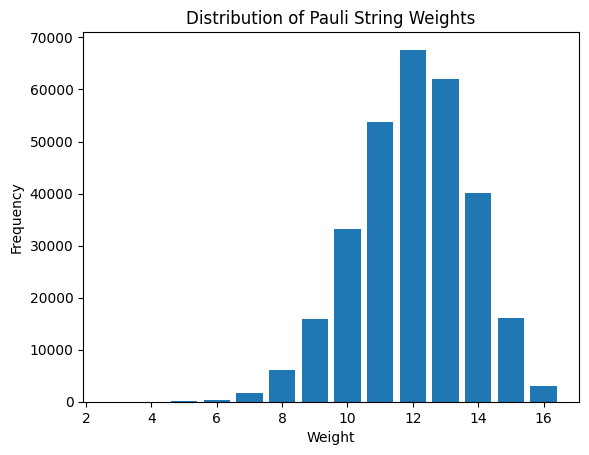

In [2]:
import matplotlib.pyplot as plt

plt.hist(weights, bins=range(min(weights), max(weights) + 2), align='left', rwidth=0.8)
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Distribution of Pauli String Weights")
plt.show()